# Sonrisa o no sonrisa → Clasificación de imágenes

Este notebook carga el **ZIP** con un subcojunto del dataset de CelebA, entrena una red neuronal convolucional simple y permite predecir en una imagen propia.


## 2) Crear `tf.data` datasets desde la carpeta

In [37]:
import os
import tensorflow as tf
from google.colab import drive

# Montar Google Drive
drive.mount("/content/drive")

# Ruta de la carpeta en Google Drive
BASE_DIR = "/content/drive/MyDrive/dataset_smile"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Verificar que las carpetas sí existen
for path in [BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, "->", os.path.exists(path))

IMG_SIZE = 160
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=False
)

class_names = train_ds.class_names
print("Clases:", class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/dataset_smile -> True
/content/drive/MyDrive/dataset_smile/train -> True
/content/drive/MyDrive/dataset_smile/val -> True
/content/drive/MyDrive/dataset_smile/test -> True
Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Clases: ['0_no_smile', '1_smile']


## 3) Ver 3 ejemplos por clase

Found 1400 files belonging to 2 classes.


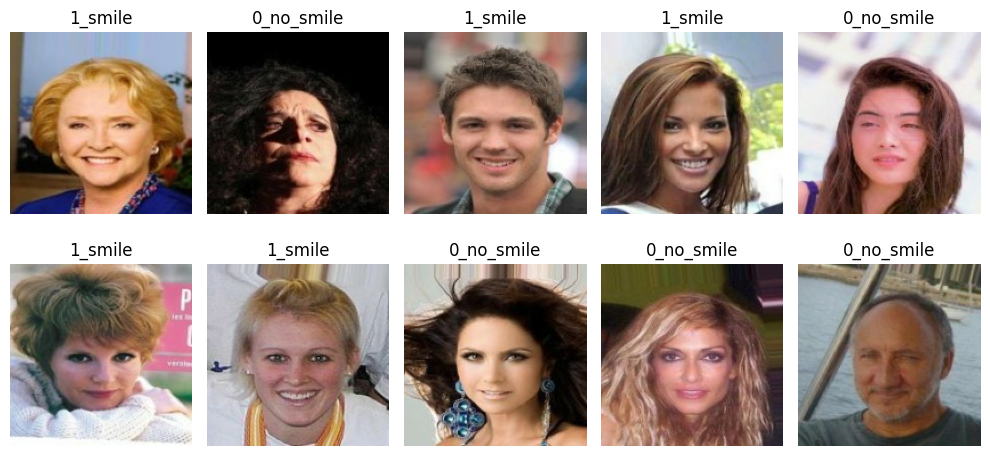

In [38]:

import matplotlib.pyplot as plt
import tensorflow as tf

images, labels = next(iter(tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=64, shuffle=True
)))

plt.figure(figsize=(10, 5))
shown_per_class = {c:0 for c in range(len(class_names))}
pos = 1
for img, lab in zip(images, labels):
    c = int(lab.numpy())
    if shown_per_class[c] < 5:
        plt.subplot(2, 5, pos)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(class_names[c])
        plt.axis('off')
        shown_per_class[c] += 1
        pos += 1
    if all(v >= 5 for v in shown_per_class.values()):
        break
plt.tight_layout()
plt.show()


## 4) Aumento de datos

Found 1400 files belonging to 2 classes.


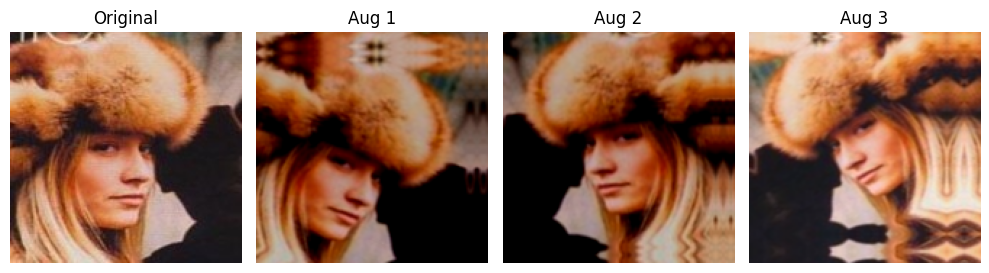

In [39]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augment")

# Revisar ejemplos
_preview_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=8, shuffle=True
)
sample_images, sample_labels = next(iter(_preview_ds))
one_img = sample_images[0:1]

augmented_examples = [data_augmentation(one_img, training=True) for _ in range(3)]

plt.figure(figsize=(10,3))
plt.subplot(1,4,1); plt.imshow(sample_images[0].numpy().astype("uint8")); plt.title("Original"); plt.axis('off')
for i, aug in enumerate(augmented_examples, start=2):
    plt.subplot(1,4,i)
    plt.imshow(tf.cast(tf.clip_by_value(aug[0], 0, 255), tf.uint8).numpy())
    plt.title(f"Aug {i-1}")
    plt.axis('off')
plt.tight_layout(); plt.show()


## 5) Construcción de una CNN simple

In [40]:

from tensorflow.keras import layers, models
import tensorflow as tf

num_classes = len(class_names)

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_cnn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
# Parámetros = (w x h x ch + 1) x filters


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │       102,402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,826 (944.63 KB)

 Trainable params: 241,826 (944.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6) Entrenamiento con Early Stopping

In [41]:

from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 100
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.5221 - loss: 0.7146 - val_accuracy: 0.5733 - val_loss: 0.6888
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5314 - loss: 0.6925 - val_accuracy: 0.5600 - val_loss: 0.6918
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5443 - loss: 0.6902 - val_accuracy: 0.5767 - val_loss: 0.6899
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5229 - loss: 0.6926 - val_accuracy: 0.5400 - val_loss: 0.6869
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.5436 - loss: 0.6888 - val_accuracy: 0.5000 - val_loss: 0.7011
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5150 - loss: 0.6919 - val_accuracy: 0.5600 - val_loss: 0.6909
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5686 - loss: 0.6817 - val_accuracy: 0.5933 - val_loss: 0.6716
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5836 - loss: 0.6773 - val_accuracy: 0.

## 7) Gráficas de resultados

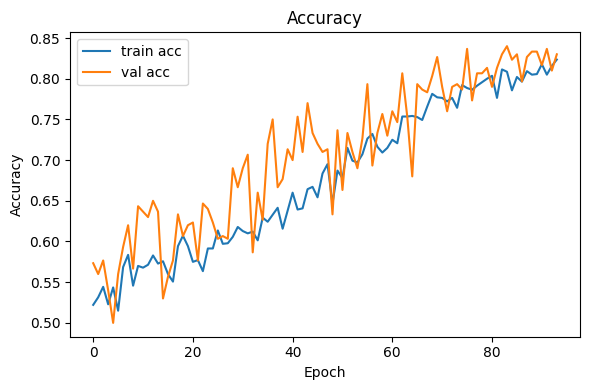

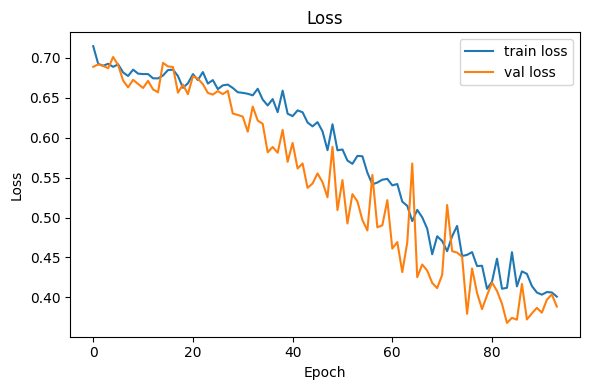

In [42]:

import matplotlib.pyplot as plt

acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

plt.figure(figsize=(6,4))
plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy'); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss'); plt.tight_layout(); plt.show()


## 8) Matriz de confusión en test

Found 300 files belonging to 2 classes.
Classification report:
              precision    recall  f1-score   support

  0_no_smile      0.823     0.867     0.844       150
     1_smile      0.859     0.813     0.836       150

    accuracy                          0.840       300
   macro avg      0.841     0.840     0.840       300
weighted avg      0.841     0.840     0.840       300



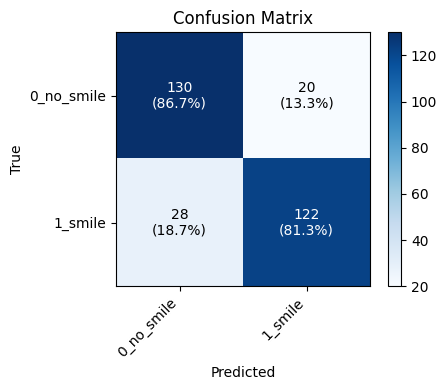

In [43]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predicciones
y_true, y_pred = [], []
for images, labels in tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_names=class_names, shuffle=False
):
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Graficar con anotaciones
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Títulos y etiquetas
ax.set_title("Confusion Matrix")
ax.set_xticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(np.arange(len(class_names)))
ax.set_yticklabels(class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

# Anotar cada celda con conteo y proporción por fila
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # proporción por clase verdadera
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 9) Sube una imagen nueva y predice (Smiling / Not Smiling)

Predicción: 0_no_smile (prob=0.828)


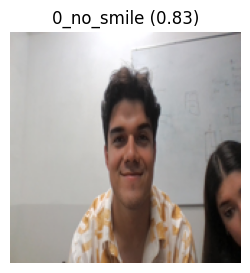

In [44]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# WIN_20260427_19_57_40_Pro
# print("Sube una imagen (.jpg/.png) con un rostro (similar a los recortes del dataset).")
# up = files.upload()
# img_path = list(up.keys())[0]

# Ruta de la carpeta en Google Drive
img_path = "/content/drive/MyDrive/WIN_20260427_19_57_40_Pro.jpg"
IMG_SIZE = 160

img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
x = np.asarray(img).astype('float32') / 1.0
x = np.expand_dims(x, axis=0)

probs = model.predict(x, verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_class = class_names[pred_idx]
pred_prob = float(probs[pred_idx])

print(f"Predicción: {pred_class} (prob={pred_prob:.3f})")

plt.figure(figsize=(3,3))
plt.imshow(img); plt.title(f"{pred_class} ({pred_prob:.2f})"); plt.axis('off'); plt.show()
